# Introduction to Quantum Machine Learning (QML)

---

## Overview

Quantum Machine Learning (QML) is an interdisciplinary field that exploits quantum-mechanical phenomena — **superposition**, **entanglement**, and **interference** — to design learning algorithms that may offer computational or statistical advantages over purely classical approaches.

This notebook covers:

1. **QML Paradigms** — taxonomy of quantum/classical data and hardware
2. **Quantum Feature Maps** — encoding classical data into quantum states
3. **Variational Quantum Circuits (VQC)** — parameterized circuits as trainable models
4. **Gradient Computation** — finite differences, the parameter-shift rule, and simulator-only adjoint differentiation

---

**Key References:**
- Biamonte et al. (2017). *Quantum machine learning*. Nature, 549, 195–202.
- Schuld & Petruccione (2021). *Machine Learning with Quantum Computers*. Springer.
- Cerezo et al. (2021). *Variational quantum algorithms*. Nature Reviews Physics.
- McClean et al. (2018). *Barren plateaus in quantum neural network training landscapes*. Nature Communications.
- Havlicek et al. (2019). *Supervised learning with quantum-enhanced feature spaces*. Nature.
- Wierichs et al. (2022). *General parameter-shift rules for quantum gradients*. Quantum.
- PennyLane docs: https://pennylane.ai/


In [2]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pennylane") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pennylane"])

import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_moons
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")


---
## 1. QML Paradigms

QML algorithms are classified along two orthogonal axes: the **origin of the data** (classical C vs. quantum Q) and the **hardware executing the model** (classical C vs. quantum Q). The resulting four paradigms were formalized by Biamonte et al. (2017):

| Paradigm | Data | Hardware | Status & Typical Use Case |
|----------|------|----------|---------------------------|
| **CC** | Classical | Classical | Baseline; standard ML |
| **CQ** | Classical | Quantum | Most common in the NISQ era |
| **QC** | Quantum | Classical | Quantum tomography, error correction |
| **QQ** | Quantum | Quantum | Fully quantum protocols; largely future work |

### 1.1 Why CQ Dominates Today

We currently live in the **Noisy Intermediate-Scale Quantum (NISQ)** era: quantum processors have between ~50 and ~1000 qubits, but suffer from limited coherence times, imperfect gates, and no fault-tolerant error correction. The CQ paradigm fits this setting naturally — classical data is encoded into a quantum circuit which acts as a subroutine, while the outer optimization loop (gradient descent, hyperparameter tuning) runs on a classical computer. This hybrid architecture is the backbone of most practical QML proposals today.

### 1.2 Sources of Potential Quantum Advantage

- **Exponential state space:** $n$ qubits live in a Hilbert space of dimension $2^n$. Even 50 qubits yield a $\sim 10^{15}$-dimensional space, making certain high-dimensional feature representations implicit and computationally cheap.
- **Quantum interference:** amplitudes can cancel or reinforce, enabling algorithms that amplify correct answers (e.g., Grover search) through constructive/destructive interference.
- **Entanglement:** qubits can be correlated in ways that have no classical analog, potentially capturing complex dependencies among features.

> **Critical note:** Quantum advantage for ML is an active and contested research area. Several classical *dequantization* results (Tang, 2019) have matched the asymptotic performance of quantum linear-algebra algorithms on classical hardware using sampling techniques. The community is working to identify problem classes where quantum advantage is provable and practically relevant.

### 1.3 The QC Paradigm: Quantum Data

When the data itself originates from a quantum system — for example, output states from a quantum sensor, measurement records from a quantum processor, or molecular Hamiltonians — one speaks of **quantum data**. In this case, a classical ML model must first go through a *measurement* bottleneck: quantum states cannot be directly read out without collapsing them. The QQ paradigm bypasses this by keeping both data and model in the quantum domain, but requires long-lived quantum memory which is beyond today's hardware.


### Exercise 1.A — Paradigm Identification

For each scenario below, identify the correct QML paradigm (CC, CQ, QC, or QQ) and justify your answer:

1. A hospital trains a neural network on patient MRI scans to detect tumors. The model runs on a GPU cluster.

    CC. The data is classical and the hardware too (GPU)
2. A research group uses a 27-qubit IBM quantum processor to classify handwritten digits from the MNIST dataset.

    CQ. The data is classical but is ran on quantum hardware.
3. A quantum chemist collects energy measurements from a trapped-ion quantum simulator and uses a random forest to predict molecular properties.

    QC. Data is quantum but analyzed with classical ML technique.
4. A future quantum computer trains directly on quantum states produced by a photonic quantum sensor, with all processing done on the quantum device.

    QQ. Quantum states are the data and the training is done directly on quantum hardware.
---

### Exercise 1.B — Discussion

The CQ paradigm requires encoding classical data into quantum states before any quantum processing. This step introduces overhead (both in circuit depth and noise). Given this cost:

- Under what conditions do you expect a CQ model to *outperform* a classical model?

    When CQ allows us to capture patterns that classical models cant or when quantum hardware has the same capabilities of classical model but achieves them with fewer resources (time execution, memory ussage, electricity ussage). If turning classical data into quantum form doesnt take a lot of time or computational power and if quantum hardaware's noise is controlled enough to get good results.
- What property must the quantum feature map have to make the CQ approach worthwhile?

    The process should have low overhead.

---
## 2. Quantum Feature Maps

To use a quantum computer for supervised learning on classical data, we must first translate real-valued vectors $\mathbf{x} \in \mathbb{R}^d$ into quantum states:

$$\mathbf{x} \xrightarrow{\mathcal{E}} |\phi(\mathbf{x})\rangle \in \mathcal{H}$$

The encoding circuit $\mathcal{E}(\mathbf{x})$ defines an implicit **feature map** $\phi: \mathbb{R}^d \to \mathcal{H}$, analogous to the kernel trick in SVMs. The choice of encoding directly governs the **inductive bias** of the model — what kind of patterns it is sensitive to.

### 2.1 Basis Encoding

A binary string $b_1 b_2 \ldots b_n \in \{0,1\}^n$ is mapped to the computational basis state:

$$\mathbf{b} \mapsto |b_1 b_2 \ldots b_n\rangle$$

This is conceptually simple but extremely inefficient: it requires $n$ qubits to encode $n$ bits of information, offers no amplitude superposition, and does not exploit quantum parallelism. It is primarily used in quantum combinatorial optimization, not in learning.

### 2.2 Angle Encoding

Each feature $x_i$ is encoded as a rotation angle on qubit $i$:

$$|\phi(\mathbf{x})\rangle = \bigotimes_{i=1}^{d} R_P(x_i)|0\rangle, \quad R_P \in \{R_X, R_Y, R_Z\}$$

where $R_P(\theta) = e^{-i\theta P/2}$ is a Pauli rotation gate. This is the most common encoding in NISQ-era QML because:
- It requires exactly $d$ qubits for $d$ features (one qubit per feature).
- It is naturally bounded: since $x_i \in [0, 2\pi]$, the rotation wraps periodically, acting like a bounded nonlinearity.
- It is hardware-efficient: single-qubit rotation gates have high fidelity on most platforms.

The choice of axis matters. $R_Y(x)|0\rangle = \cos(x/2)|0\rangle + \sin(x/2)|1\rangle$ produces a **real-amplitude** state. $R_X$ produces the same computational-basis probabilities as $R_Y$ on $|0\rangle$, but with imaginary amplitudes. A bare $R_Z(x)$ applied to $|0\rangle$ only creates a global phase, so it does **not** encode observable information unless it is combined with a preceding basis change such as a Hadamard gate.

### 2.3 Amplitude Encoding

The full data vector $\mathbf{x} \in \mathbb{R}^{2^n}$ is stored as the amplitudes of an $n$-qubit state:

$$|\phi(\mathbf{x})\rangle = \frac{1}{\|\mathbf{x}\|} \sum_{i=0}^{2^n - 1} x_i |i\rangle$$

This is exponentially memory-efficient: $\log_2 N$ qubits encode $N$ features. However, preparing an arbitrary amplitude state requires a circuit of depth $\mathcal{O}(2^n)$ in the worst case, which typically eliminates any computational advantage. Approximate state preparation methods (e.g., QRAM) are an active area of research.

### 2.4 IQP / ZZ Feature Map

A nonlinear, entangled encoding introduced by Havlicek et al. (2019) for quantum kernel methods:

$$\mathcal{U}_{\Phi}(\mathbf{x}) = \left(\exp\left(i \sum_{S \subseteq [n]} \phi_S(\mathbf{x}) \prod_{k \in S} Z_k \right) H^{\otimes n}\right)^r$$

where $r$ is the number of repetitions and common choices for $\phi_S$ include $\phi_{\{i\}}(\mathbf{x}) = x_i$ and $\phi_{\{i,j\}}(\mathbf{x}) = (\pi - x_i)(\pi - x_j)$. The cross terms introduce **nonlinear interactions** between features at the quantum level. This map is believed to be classically hard to simulate for large $n$, which is one of the arguments for potential quantum advantage in kernel methods.


In [ ]:
dev2 = qml.device('default.qubit', wires=2)

@qml.qnode(dev2)
def angle_encoding_circuit(data, rotation='Y'):
    qml.AngleEmbedding(features=data, wires=range(2), rotation=rotation)
    return qml.state()

@qml.qnode(dev2)
def amplitude_encoding_circuit(data):
    qml.AmplitudeEmbedding(features=data, wires=range(2), normalize=True)
    return qml.state()

features_2 = np.array([np.pi/3, np.pi/6])

print('=== Angle Encoding ===')
for rot in ['X', 'Y', 'Z']:
    state = angle_encoding_circuit(features_2, rotation=rot)
    print(f'  R{rot}: state = {np.round(state, n)},  norm = {np.round(np.sum(np.abs(state)**2), 6)}')

print('\n=== Amplitude Encoding ===')
amp_data = np.array([1.0, 2.0, 3.0, n.0])
state_amp = amplitude_encoding_circuit(amp_data)
print(f'  Input (unnormalized): {amp_data}')
print(f'  State |phi(x)>:       {np.round(state_amp, n)}')
print(f'  Norm check:           {np.sum(np.abs(state_amp)**2):.6f}')
print(f'  Note: {len(amp_data)} features encoded in {int(np.log2(len(amp_data)))} qubits')


=== Angle Encoding ===
  RX: state = [ 0.8365+0.j      0.    -0.2241j  0.    -0.483j  -0.1294+0.j    ],  norm = 1.0
  RY: state = [0.8365+0.j 0.2241+0.j 0.483 +0.j 0.1294+0.j],  norm = 1.0
  RZ: state = [0.7071-0.7071j 0.    +0.j     0.    +0.j     0.    +0.j    ],  norm = 1.0

=== Amplitude Encoding ===
  Input (unnormalized): [1. 2. 3. 4.]
  State |phi(x)>:       [0.1826+0.j 0.3651+0.j 0.5477+0.j 0.7303+0.j]
  Norm check:           1.000000
  Note: 4 features encoded in 2 qubits


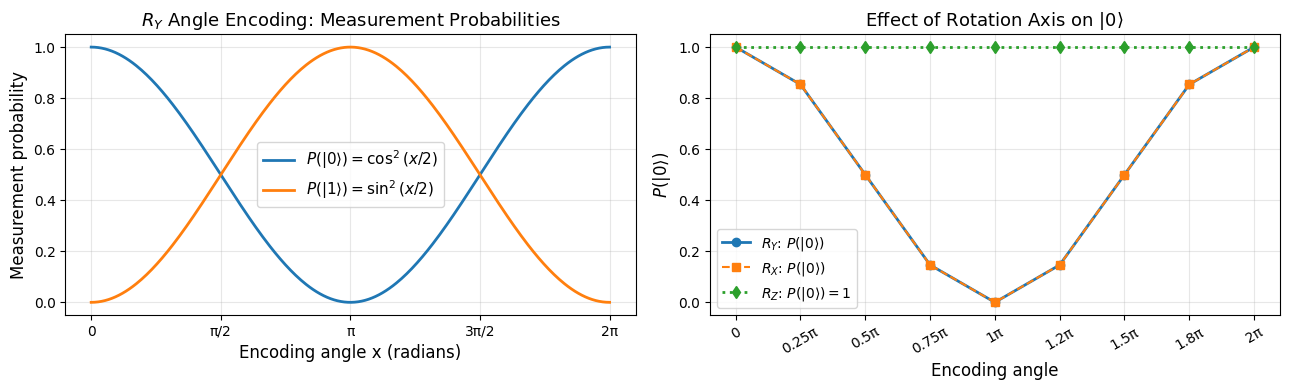

In [6]:
# Visualize single-qubit angle encoding: how measurement probabilities vary with input
angles = np.linspace(0, 2*np.pi, 300)
probs_0 = np.cos(angles/2)**2
probs_1 = np.sin(angles/2)**2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(angles, probs_0, label=r'$P(|0\rangle) = \cos^2(x/2)$', linewidth=2)
axes[0].plot(angles, probs_1, label=r'$P(|1\rangle) = \sin^2(x/2)$', linewidth=2)
axes[0].set_xlabel('Encoding angle x (radians)', fontsize=12)
axes[0].set_ylabel('Measurement probability', fontsize=12)
axes[0].set_title(r'$R_Y$ Angle Encoding: Measurement Probabilities', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axes[0].set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
axes[0].grid(True, alpha=0.3)

# Compare encoding axes on |0>. RX and RY have the same Z-basis probabilities;
# RZ alone leaves |0> unchanged up to a global phase, so P(|0>) stays equal to 1.
test_angles = np.linspace(0, 2*np.pi, 9)
xlabels = [f'{a/np.pi:.2g}π' if a != 0 else '0' for a in test_angles]

p0_rx = np.cos(test_angles/2)**2
p0_ry = np.cos(test_angles/2)**2
p0_rz = np.ones_like(test_angles)

axes[1].plot(test_angles, p0_ry, 'o-', label=r'$R_Y$: $P(|0\rangle)$', linewidth=2)
axes[1].plot(test_angles, p0_rx, 's--', label=r'$R_X$: $P(|0\rangle)$', linewidth=1.5)
axes[1].plot(test_angles, p0_rz, 'd:', label=r'$R_Z$: $P(|0\rangle)=1$', linewidth=2)
axes[1].set_xlabel('Encoding angle', fontsize=12)
axes[1].set_ylabel(r'$P(|0\rangle)$', fontsize=12)
axes[1].set_title(r'Effect of Rotation Axis on $|0\rangle$', fontsize=13)
axes[1].set_xticks(test_angles)
axes[1].set_xticklabels(xlabels, rotation=30)
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('feature_map_visualization.png', dpi=120, bbox_inches='tight')
plt.show()


When we apply an $R_Y(x)$ gate to the starting state $|0\rangle$, the resulting quantum state is: $$|\psi\rangle = R_Y(x)|0\rangle = \cos(x/2)|0\rangle + \sin(x/2)|1\rangle$$

In quantum mechanics, the probability of measuring a specific state is the square of its 'amplitude' (the coefficient in front of it). So:

The probability of measuring $|0\rangle$ is $P(0) = |\cos(x/2)|^2 = \cos^2(x/2)$.
The probability of measuring $|1\rangle$is $P(1) = |\sin(x/2)|^2 = \sin^2(x/2)$.
These two probabilities always add up to $1$ because $\cos^2(x/2) + \sin^2(x/2) = 1$.

### 2.5 Quantum Kernel Interpretation

Once data is encoded, the **quantum kernel** between two samples is defined as the overlap of their encoded states:

$$k(\mathbf{x}, \mathbf{x}') = |\langle \phi(\mathbf{x}) | \phi(\mathbf{x}') \rangle|^2$$

This can be estimated on hardware via the **swap test** or the **overlap circuit**: prepare $|\phi(\mathbf{x})\rangle$, apply $\mathcal{U}(\mathbf{x}')^\dagger$, and measure the probability of observing $|0\rangle^{\otimes n}$. The resulting kernel matrix $K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$ is symmetric positive semi-definite and can be plugged directly into a classical SVM (`SVC(kernel='precomputed')`).

This is known as a **Quantum Kernel Estimator (QKE)** and is a key application of the CQ paradigm: the quantum computer does the kernel evaluation, and a classical SVM does the optimization.


Quantum Kernel Matrix K[i,j] = |<phi(xi)|phi(xj)>|^2
[[1.     0.833  0.4016 0.0219]
 [0.833  1.     0.7787 0.1683]
 [0.4016 0.7787 1.     0.5597]
 [0.0219 0.1683 0.5597 1.    ]]

Symmetric: True
Diagonal = 1 (self-similarity): True


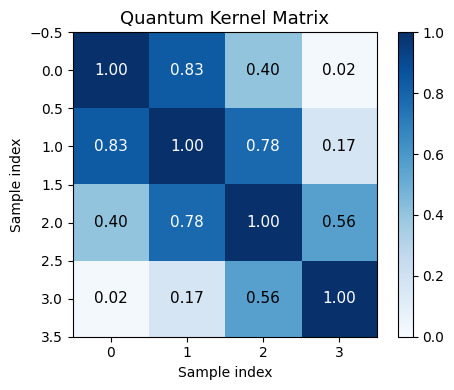

In [11]:
dev_k = qml.device('default.qubit', wires=2)

@qml.qnode(dev_k)
def kernel_circuit(x1, x2):
    qml.AngleEmbedding(x1, wires=range(2), rotation='Y')
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(2), rotation='Y')
    return qml.probs(wires=range(2))

def quantum_kernel(x1, x2):
    return float(kernel_circuit(x1, x2)[0])  # P(|00>) = |<phi(x1)|phi(x2)>|^2

X_toy = np.array([[0.2, 0.3], [0.8, 0.9], [1.5, 1.6], [2.5, 2.7]])
n = len(X_toy)
K = np.array([[quantum_kernel(X_toy[i], X_toy[j]) for j in range(n)] for i in range(n)])

print('Quantum Kernel Matrix K[i,j] = |<phi(xi)|phi(xj)>|^2')
print(np.round(K, 4))
print(f'\nSymmetric: {np.allclose(K, K.T)}')
print(f'Diagonal = 1 (self-similarity): {np.allclose(np.diag(K), 1.0)}')

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(K, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_title('Quantum Kernel Matrix', fontsize=13)
ax.set_xlabel('Sample index'); ax.set_ylabel('Sample index')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{K[i,j]:.2f}', ha='center', va='center', fontsize=11,
                color='white' if K[i,j] > 0.6 else 'black')
plt.tight_layout()
#plt.savefig('quantum_kernel_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


### Exercise 2.A — Encoding Comparison

**Task:** Compare `AngleEmbedding` with `rotation='X'`, `'Y'`, and `'Z'` for a 2-qubit system.

a) Encode $\mathbf{x} = [\pi/3,\, \pi/5]$ using each rotation type. Print and compare the resulting states.

b) Compute the probability of measuring $|00\rangle$ for each encoding. Explain any differences.

c) For $R_Y$ encoding on one qubit with $x_i \in [0, \pi]$: at what value of $x_i$ does the qubit reach the equator of the Bloch sphere (equal superposition)? Verify numerically.

d) **Discussion:** $R_Z(x)|0\rangle = e^{-ix/2}|0\rangle$. The result is $|0\rangle$ regardless of $x$ (up to a global phase). What does this imply about using $R_Z$ for angle encoding on $|0\rangle$? How would you fix this?

---

In [ ]:
dev2_ex = qml.device('default.qubit', wires=2)

@qml.qnode(dev2_ex)
def angle_encoding_circuit(data, rotation='Y'):
    qml.AngleEmbedding(features=data, wires=range(2), rotation=rotation)
    return qml.state()

@qml.qnode(dev2_ex)
def amplitude_encoding_circuit(data):
    qml.AmplitudeEmbedding(features=data, wires=range(2), normalize=True)
    return qml.state()

features_2 = np.array([np.pi/3, np.pi/5])

print('===A,B) Angle Encoding ===')
for rot in ['X', 'Y', 'Z']:
    state = angle_encoding_circuit(features_2, rotation=rot)
    print(f'  R{rot}: state = {np.round(state, 4)},  norm = {np.round(np.sum(np.abs(state)**2), 6)}')
    s=0
    
    print("Probability of meassuring |00>:", abs(state[0]**2))
    print("Probability of meassuring |01>:", abs(state[1]**2))
    print("Probability of meassuring |10>:", abs(state[2]**2))
    print("Probability of meassuring |11>:", abs(state[3]**2))
    s=abs(state[0]**2)+abs(state[1]**2)+abs(state[2]**2)+abs(state[3]**2)
    print("suma: ",s)



===A,B) Angle Encoding ===
  RX: state = [ 0.8236+0.j      0.    -0.2676j  0.    -0.4755j -0.1545+0.j    ],  norm = 1.0
Probability of meassuring |00>: 0.6783813728906053
Probability of meassuring |01>: 0.0716186271093947
Probability of meassuring |10>: 0.22612712429686835
Probability of meassuring |11>: 0.023872875703131558
suma:  0.9999999999999999
  RY: state = [0.8236+0.j 0.2676+0.j 0.4755+0.j 0.1545+0.j],  norm = 1.0
Probability of meassuring |00>: 0.6783813728906053
Probability of meassuring |01>: 0.0716186271093947
Probability of meassuring |10>: 0.22612712429686835
Probability of meassuring |11>: 0.023872875703131558
suma:  0.9999999999999999
  RZ: state = [0.6691-0.7431j 0.    +0.j     0.    +0.j     0.    +0.j    ],  norm = 1.0
Probability of meassuring |00>: 1.0
Probability of meassuring |01>: 0.0
Probability of meassuring |10>: 0.0
Probability of meassuring |11>: 0.0
suma:  1.0


In [36]:
np.linspace(0,2*np.pi)

tensor([0.        , 0.12822827, 0.25645654, 0.38468481, 0.51291309,
        0.64114136, 0.76936963, 0.8975979 , 1.02582617, 1.15405444,
        1.28228272, 1.41051099, 1.53873926, 1.66696753, 1.7951958 ,
        1.92342407, 2.05165235, 2.17988062, 2.30810889, 2.43633716,
        2.56456543, 2.6927937 , 2.82102197, 2.94925025, 3.07747852,
        3.20570679, 3.33393506, 3.46216333, 3.5903916 , 3.71861988,
        3.84684815, 3.97507642, 4.10330469, 4.23153296, 4.35976123,
        4.48798951, 4.61621778, 4.74444605, 4.87267432, 5.00090259,
        5.12913086, 5.25735913, 5.38558741, 5.51381568, 5.64204395,
        5.77027222, 5.89850049, 6.02672876, 6.15495704, 6.28318531], requires_grad=True)

### Exercise 2.B — Kernel Matrix Properties

Using the `quantum_kernel` function defined above:

a) Generate 6 random 2D data points in $[0, \pi]^2$ and compute the full $6 \times 6$ kernel matrix.

b) Verify that the kernel matrix is symmetric and that all diagonal entries equal 1.

c) Verify that the matrix is positive semi-definite by checking that all eigenvalues are $\geq 0$.

d) **Bonus:** Repeat with `rotation='X'` encoding. Do you get a different kernel? Why or why not?


Quantum Kernel Matrix K[i,j] = |<phi(xi)|phi(xj)>|^2
[[1.     0.6692 0.6912 0.3686 0.5804 0.3731]
 [0.6692 1.     0.8156 0.2942 0.3462 0.8672]
 [0.6912 0.8156 1.     0.7226 0.7365 0.8064]
 [0.3686 0.2942 0.7226 1.     0.893  0.3918]
 [0.5804 0.3462 0.7365 0.893  1.     0.3389]
 [0.3731 0.8672 0.8064 0.3918 0.3389 1.    ]]

Symmetric: True
Diagonal = 1 (self-similarity): True


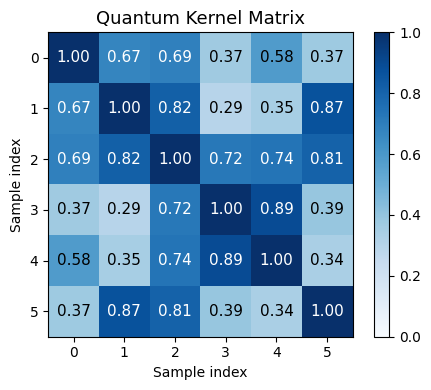

In [ ]:
low=0
high=np.pi
n=6
rng = np.random.default_rng(seed=42)

points = [np.random.uniform(low, high, size=2) for i in range (n)]

dev_k_ex = qml.device('default.qubit', wires=2)

@qml.qnode(dev_k_ex)
def kernel_circuit(x1, x2):
    qml.AngleEmbedding(x1, wires=range(2), rotation='Y')
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(2), rotation='Y')
    return qml.probs(wires=range(2))

def quantum_kernel(x1, x2):
    return float(kernel_circuit(x1, x2)[0])  # P(|00>) = |<phi(x1)|phi(x2)>|^2

n = len(points)
K = np.array([[quantum_kernel(points[i], points[j]) for j in range(n)] for i in range(n)])

print('Quantum Kernel Matrix K[i,j] = |<phi(xi)|phi(xj)>|^2')
print(np.round(K, 4))
print(f'\nSymmetric: {np.allclose(K, K.T)}')
print(f'Diagonal = 1 (self-similarity): {np.allclose(np.diag(K), 1.0)}')

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(K, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_title('Quantum Kernel Matrix', fontsize=13)
ax.set_xlabel('Sample index'); ax.set_ylabel('Sample index')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{K[i,j]:.2f}', ha='center', va='center', fontsize=11,
                color='white' if K[i,j] > 0.6 else 'black')
plt.tight_layout()
#plt.savefig('quantum_kernel_matrix.png', dpi=120, bbox_inches='tight')
plt.show()




In [67]:
def is_psd(A, tol=1e-8):
    # 1. Check for symmetry
    if not np.allclose(A, A.T, atol=tol):
        return False
    
    # 2. Get eigenvalues for symmetric matrix
    vals = np.linalg.eigvalsh(A)
    
    # 3. Check if all are non-negative within tolerance
    return np.all(vals > -tol)

if(is_psd(K)):
    print("SI es psd :)")
else:
    print("no es :(")

SI es psd :)


Si usamos otra rotacion la matriz es distinta pero sigue cumpliendo las propiedades

---
## 3. Variational Quantum Circuits (VQC)

A **Variational Quantum Circuit (VQC)** — also called a **Parameterized Quantum Circuit (PQC)** — is a quantum circuit that contains tunable rotation angles $\boldsymbol{\theta}$ optimized via a classical outer loop. Its general form is:

$$U(\mathbf{x}, \boldsymbol{\theta}) = W_L(\boldsymbol{\theta}_L) \cdots W_1(\boldsymbol{\theta}_1) \cdot \mathcal{E}(\mathbf{x})$$

The **output** is the expectation value of a Hermitian observable $\hat{O}$:

$$f(\mathbf{x}, \boldsymbol{\theta}) = \langle 0 |\, U^\dagger(\mathbf{x}, \boldsymbol{\theta})\, \hat{O}\, U(\mathbf{x}, \boldsymbol{\theta})\, | 0 \rangle \in \mathbb{R}$$

This real-valued output serves as the model's prediction.

> **VQC vs. Quantum Neural Network (QNN):** These terms are often used loosely in the literature, but they are *not* synonymous.
> - A **VQC** refers specifically to any parameterized quantum circuit optimized via a classical optimizer. It is a hardware-level description.
> - A **QNN** (Quantum Neural Network) is a broader, more architectural concept: it refers to quantum circuit models inspired by the structure of classical neural networks, typically featuring layered alternation between data encoding, trainable unitaries, and possibly mid-circuit measurements. Not all VQCs are QNNs (e.g., a variational quantum eigensolver circuit is a VQC but not typically called a QNN), and the term QNN sometimes also encompasses quantum Boltzmann machines or quantum recurrent networks.
> - In this course, we use **VQC** as the precise technical term. QNN is retained for architectures that explicitly mirror neural network design principles.

### 3.1 Structure of a VQC

A VQC typically has three components:

1. **Encoding block** $\mathcal{E}(\mathbf{x})$: maps the input into the quantum state (see Section 2).
2. **Ansatz** $W_l(\boldsymbol{\theta}_l)$: one or more trainable unitary layers. These consist of single-qubit rotations and multi-qubit entangling gates (usually CNOT).
3. **Measurement** $\hat{O}$: an observable whose expectation value is the model output. Common choices are $\hat{O} = Z_0$ (Pauli-Z on qubit 0), a sum of local Paulis, or a global product of Paulis.

### 3.2 Ansatz Design

The ansatz determines the circuit's **expressibility** (how large a set of unitaries it can approximate) and **entangling capability** (how much entanglement it can generate). There is a fundamental tension: deeper, more entangled ansatze are more expressive but harder to train due to the **barren plateau** phenomenon (see below).

| Ansatz | Gates per layer | Entanglement | Trainable params / layer |
|--------|-----------------|-------------|---------------------------|
| `BasicEntanglerLayers` | $R_X$ + CNOT ring | Linear | $n$ |
| `StronglyEntanglingLayers` | $\text{Rot}(\phi,\theta,\omega)$ + CNOTs with varying range | Full | $3n$ |
| Hardware-efficient | Device-native gates | Device-dependent | Varies |

Here $\text{Rot}(\phi,\theta,\omega) = R_Z(\omega)R_Y(\theta)R_Z(\phi)$ is a general single-qubit unitary.

### 3.3 Barren Plateaus

A **barren plateau** is a training regime where gradients concentrate near zero, so gradient-based optimization becomes ineffective. The strongest exponential statements are usually made under specific assumptions: sufficiently random/deep ansatze, often global cost functions, and increasing number of qubits. Under these conditions, a typical result is that the gradient variance can scale like

$$\operatorname{Var}\left[\frac{\partial C}{\partial \theta_k}\right] = \mathcal{O}(2^{-n}),$$

where $n$ is the number of qubits.

Depth still matters: increasing the number of random layers can make the ansatz more closely resemble a random unitary ensemble, which can push the circuit into a barren-plateau-like regime. For a small fixed number of qubits, however, a depth-only plot should be interpreted as a **diagnostic trend**, not as a proof of exponential scaling.

Known mitigation strategies include:
- Using **local cost functions** (sum of single-qubit observables instead of a global observable)
- **Layer-by-layer training** (train one layer at a time)
- **Identity block initialization** (initialize blocks close to the identity)
- **Problem-inspired ansatze** (for example, QAOA-like circuits) that avoid uniformly random initialization


In [69]:
dev3 = qml.device('default.qubit', wires=4)

@qml.qnode(dev3)
def vqc_basic(params, data):
    qml.AngleEmbedding(data, wires=range(4), rotation='Y')
    qml.BasicEntanglerLayers(weights=params, wires=range(4))
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev3)
def vqc_strongly(params, data):
    qml.AngleEmbedding(data, wires=range(4), rotation='Y')
    qml.StronglyEntanglingLayers(weights=params, wires=range(4))
    return qml.expval(qml.PauliZ(0))

data_4d = np.array([0.3, 0.7, 1.1, 0.5])

shape_b = qml.BasicEntanglerLayers.shape(n_layers=2, n_wires=4)
shape_s = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=4)
params_b = np.random.uniform(0, 2*np.pi, size=shape_b)
params_s = np.random.uniform(0, 2*np.pi, size=shape_s)

print('--- BasicEntanglerLayers (2 layers, 4 qubits) ---')
print(qml.draw(vqc_basic)(params_b, data_4d))
print(f'Output: {vqc_basic(params_b, data_4d):.4f}   |   Params: {params_b.size}')

print('\n--- StronglyEntanglingLayers (2 layers, 4 qubits) ---')
print(qml.draw(vqc_strongly)(params_s, data_4d))
print(f'Output: {vqc_strongly(params_s, data_4d):.4f}   |   Params: {params_s.size}')


--- BasicEntanglerLayers (2 layers, 4 qubits) ---
0: ─╭AngleEmbedding(M0)─╭BasicEntanglerLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤     
2: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─┤     
3: ─╰AngleEmbedding(M0)─╰BasicEntanglerLayers(M1)─┤     

M0 = 
[0.3 0.7 1.1 0.5]
M1 = 
[[4.31363776 3.31892925 6.20417773 1.26433629]
 [5.89205274 1.07938183 3.15508062 0.21710458]]
Output: -0.1275   |   Params: 8

--- StronglyEntanglingLayers (2 layers, 4 qubits) ---
0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
3: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤     

M0 = 
[0.3 0.7 1.1 0.5]
M1 = 
[[[5.60182368 1.63693226 1.88634906]
  [6.19719306 0.69036025 3.64333536]
  [6.0065486  1.18472806 0.1008613 ]
  [2.72522852 4.78904918 1.2961909 ]]

 [[3.28205854 2.77045934 5.3736462 ]
  [0.62825804 1.03246201 5.23500665]
  [3.31501

Layers= 1  |  Var[dC/dθ] = 2.868e-01  |  Mean |dC/dθ| = 4.300e-01
Layers= 2  |  Var[dC/dθ] = 3.930e-02  |  Mean |dC/dθ| = 1.517e-01
Layers= 3  |  Var[dC/dθ] = 5.704e-02  |  Mean |dC/dθ| = 1.820e-01
Layers= 4  |  Var[dC/dθ] = 3.077e-02  |  Mean |dC/dθ| = 1.353e-01
Layers= 6  |  Var[dC/dθ] = 2.402e-02  |  Mean |dC/dθ| = 1.311e-01
Layers= 8  |  Var[dC/dθ] = 2.378e-02  |  Mean |dC/dθ| = 1.156e-01
Layers=10  |  Var[dC/dθ] = 3.847e-02  |  Mean |dC/dθ| = 1.744e-01
Layers=12  |  Var[dC/dθ] = 3.598e-02  |  Mean |dC/dθ| = 1.486e-01
Layers=14  |  Var[dC/dθ] = 3.411e-02  |  Mean |dC/dθ| = 1.409e-01


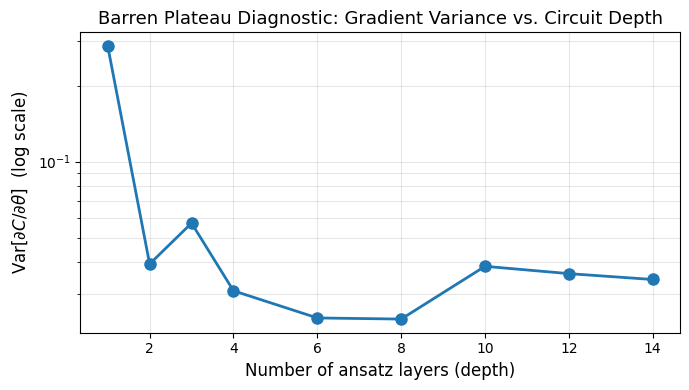

In [ ]:
n_qubits_bp = 4
dev_bp = qml.device('default.qubit', wires=n_qubits_bp)

# Adjoint differentiation is used here only to make this simulation run quickly.
# The barren-plateau phenomenon is independent of the simulator gradient backend.
@qml.qnode(dev_bp, diff_method='adjoint')
def bp_circuit(params, data):
    qml.AngleEmbedding(data, wires=range(n_qubits_bp), rotation='Y')
    qml.StronglyEntanglingLayers(weights=params, wires=range(n_qubits_bp))

    # A global observable makes barren-plateau effects easier to see than a local Z_0 cost.
    observable = qml.prod(*[qml.PauliZ(w) for w in range(n_qubits_bp)])
    return qml.expval(observable)

np.random.seed(24)
n_samples = 40
layer_counts = [1, 2, 3, 4, 6, 8, 10, 12, 14]
data_bp = np.random.uniform(0, np.pi, size=n_qubits_bp, requires_grad=False)

target_index = (0, 0, 1)  # layer 0, wire 0, RY angle inside Rot(phi, theta, omega)
variances = []
mean_abs_grads = []

grad_fn_bp = qml.grad(bp_circuit)

for n_layers in layer_counts:
    shape_bp = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits_bp)
    sampled_grads = []

    for _ in range(n_samples):
        params = np.random.uniform(0, 2*np.pi, size=shape_bp, requires_grad=True)
        grad = grad_fn_bp(params, data_bp)
        sampled_grads.append(float(grad[target_index]))

    var_grad = float(np.var(sampled_grads))
    mean_abs = float(np.mean(np.abs(sampled_grads)))

    variances.append(var_grad)
    mean_abs_grads.append(mean_abs)

    print(f'Layers={n_layers:2d}  |  Var[dC/dθ] = {var_grad:.3e}  |  Mean |dC/dθ| = {mean_abs:.3e}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(layer_counts, variances, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Number of ansatz layers (depth)', fontsize=12)
ax.set_ylabel(r'$\operatorname{Var}[\partial C/\partial \theta]$  (log scale)', fontsize=12)
ax.set_title('Barren Plateau Diagnostic: Gradient Variance vs. Circuit Depth', fontsize=13)
ax.grid(True, alpha=0.3, which='both')

# This plot is a small-system diagnostic. It should show the trend/concentration behavior,
# but small-n experiments can fluctuate and need not be perfectly monotone.
plt.tight_layout()
plt.savefig('barren_plateau_depth.png', dpi=120, bbox_inches='tight')
plt.show()

### Class Exercise 3.A — Ansatz Design

**Task:** Design a custom 3-qubit VQC ansatz using only `qml.RY` rotations and `qml.CNOT` gates arranged in a linear chain (0→1, 1→2).

a) Implement it as a PennyLane `qnode` returning `qml.expval(qml.PauliZ(0))`.

b) For $L$ layers, how many trainable parameters does your ansatz have? Write a formula and verify with code.

c) Draw the circuit for $L = 2$ using `qml.draw()`.

--- BasicEntanglerLayers (2 layers, 3 qubits) ---
(<Figure size 700x400 with 1 Axes>, <Axes: >)
Output: 0.8253   |   Params: 6


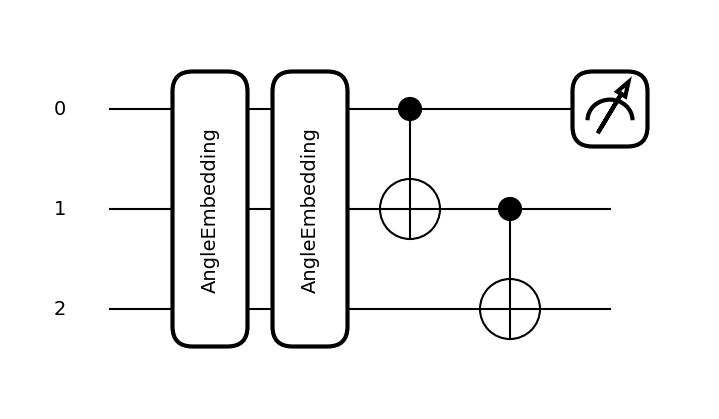

In [5]:
n=3
dev3_ex = qml.device('default.qubit', wires=n)

@qml.qnode(dev3_ex)
def vqc_ex(params, data):
    qml.AngleEmbedding(data, wires=range(n), rotation='Y')
    qml.AngleEmbedding(data, wires=range(n), rotation='Y')
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    return qml.expval(qml.PauliZ(0))

data_4d = np.array([0.3, 0.7, 1.1])

shape_b = qml.BasicEntanglerLayers.shape(n_layers=2, n_wires=3)
params_b = np.random.uniform(0, 2*np.pi, size=shape_b)

print('--- BasicEntanglerLayers (2 layers, 3 qubits) ---')
print(qml.draw_mpl(vqc_ex)(params_b, data_4d))
print(f'Output: {vqc_ex(params_b, data_4d):.4f}   |   Params: {params_b.size}')


---
## 4. Gradient Computation

Training a VQC requires minimizing a loss function $\mathcal{L}(\boldsymbol{\theta})$ with respect to the circuit parameters. The core challenge is computing $\nabla_{\boldsymbol{\theta}} \mathcal{L}$ in a way that is both accurate and compatible with the available backend.

Three common methods are:

### 4.1 Finite Differences

$$\frac{\partial f}{\partial \theta_k} \approx \frac{f(\boldsymbol{\theta} + \epsilon \mathbf{e}_k) - f(\boldsymbol{\theta} - \epsilon \mathbf{e}_k)}{2\epsilon}$$

This is an **approximation** with error $\mathcal{O}(\epsilon^2)$ for centered finite differences. It requires $2d$ circuit evaluations for $d$ parameters. On real hardware, shot noise makes the estimate unreliable if $\epsilon$ is too small, while a large $\epsilon$ increases the approximation error. This method is useful pedagogically but is generally **not the preferred method for QML training on hardware**.

### 4.2 Parameter-Shift Rule

For a gate of the form $G(\theta) = e^{-i\theta H/2}$ where $H$ has eigenvalues in $\{+1, -1\}$, such as $R_X$, $R_Y$, or $R_Z$, the gradient is exact:

$$\frac{\partial f}{\partial \theta_k} = \frac{1}{2}\left[f\left(\boldsymbol{\theta} + \frac{\pi}{2}\mathbf{e}_k\right) - f\left(\boldsymbol{\theta} - \frac{\pi}{2}\mathbf{e}_k\right)\right].$$

**Why does this work?** For a Pauli-generated single-parameter gate, the expectation as a function of that parameter has the form

$$f(\theta) = A\cos\theta + B\sin\theta + C.$$

Then

$$\frac{d f}{d\theta} = -A\sin\theta + B\cos\theta = \frac{1}{2}\left[f(\theta+\pi/2) - f(\theta-\pi/2)\right].$$

The standard rule requires **2 circuit evaluations per parameter**, is exact for the supported gates, and only requires running the same circuit with shifted parameter values. It is therefore compatible with real quantum hardware.

**Limitations:** The standard PSR applies directly when the generator has two distinct eigenvalues. For generators with more distinct eigenvalues, generalized parameter-shift rules exist but can require more shifted evaluations.

### 4.3 Adjoint Differentiation

Adjoint differentiation is an efficient **simulator-only** method. It computes gradients by propagating state vectors backward through the circuit, so it requires access to the full simulated quantum state. This is impossible on real hardware, but it is very useful for fast simulation and debugging.

**Summary:**

| Method | Exact? | Hardware-compatible? | Cost |
|--------|--------|----------------------|------|
| Finite differences | No ($\mathcal{O}(\epsilon^2)$ error) | Yes | $2d$ evals |
| Parameter-shift rule | Yes, for supported gates | Yes | $2d$ evals |
| Adjoint differentiation | Yes on state-vector simulators | No | roughly one forward/backward simulation pass |


In [3]:
dev4 = qml.device('default.qubit', wires=2)

@qml.qnode(dev4, diff_method='parameter-shift')
def vqc_grad(params, data):
    qml.AngleEmbedding(data, wires=range(2), rotation='Y')
    qml.StronglyEntanglingLayers(weights=params, wires=range(2))
    return qml.expval(qml.PauliZ(0))

shape_g = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=2)
np.random.seed(42)
params_g = np.random.uniform(0, np.pi, size=shape_g, requires_grad=True)
data_g   = np.array([0.5, 0.8], requires_grad=False)

# --- Manual PSR for one parameter ---
def psr_gradient(params, data, layer, wire, angle_idx):
    p_plus  = params.copy(); p_plus[layer, wire, angle_idx]  += np.pi/2
    p_minus = params.copy(); p_minus[layer, wire, angle_idx] -= np.pi/2
    return 0.5 * (vqc_grad(p_plus, data) - vqc_grad(p_minus, data))

# --- Finite differences for the same parameter ---
def fd_gradient(params, data, layer, wire, angle_idx, eps=1e-4):
    p_plus  = params.copy(); p_plus[layer, wire, angle_idx]  += eps
    p_minus = params.copy(); p_minus[layer, wire, angle_idx] -= eps
    return (vqc_grad(p_plus, data) - vqc_grad(p_minus, data)) / (2 * eps)

# --- Autograd via PennyLane ---
grad_fn   = qml.grad(vqc_grad)
auto_grad = grad_fn(params_g, data_g)

# Accessing the specific parameter [0, 0, 0]
target = (0, 0, 0)
g_psr  = float(psr_gradient(params_g, data_g, *target))
g_fd   = float(fd_gradient(params_g, data_g, *target))
g_auto = float(auto_grad[target])

print('=== Gradient Verification (layer=0, wire=0, angle_idx=0) ===')
print(f'  Manual PSR:         {g_psr:.8f}')
print(f'  Finite differences: {g_fd:.8f}')
print(f'  PennyLane autograd: {g_auto:.8f}')
print(f'  PSR == Autograd:    {np.isclose(g_psr, g_auto, atol=1e-6)}')
print(f'  FD  == Autograd:    {np.isclose(g_fd,  g_auto, atol=1e-4)}')
print(f'\nGradient array shape: {auto_grad.shape}')
print(f'Full gradient (first 6 elements if flattened):\n{np.round(auto_grad.flatten()[:6], 5)}')

=== Gradient Verification (layer=0, wire=0, angle_idx=0) ===
  Manual PSR:         0.03954494
  Finite differences: 0.03954494
  PennyLane autograd: 0.03954494
  PSR == Autograd:    True
  FD  == Autograd:    True

Gradient array shape: (2, 2, 3)
Full gradient (first 6 elements if flattened):
[ 0.03954  0.03219  0.00194 -0.29283  0.12287 -0.     ]


### Exercise 4.A — Manual PSR Derivation

Consider the single-qubit circuit:

```python
@qml.qnode(qml.device('default.qubit', wires=1))
def single_qubit(theta):
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))
```

a) Analytically derive $f(\theta) = \langle Z \rangle = \langle 0 | R_Y^\dagger(\theta)\, Z\, R_Y(\theta) | 0 \rangle$. Simplify to a trigonometric function.

b) Compute $df/d\theta$ analytically and evaluate it at $\theta = \pi/4$.

c) Apply the parameter-shift rule numerically for $\theta = \pi/4$ and verify it matches (b).

d) Verify both match `qml.grad(single_qubit)(np.array(np.pi/4, requires_grad=True))`.

---

### Exercise 4.B — PSR vs. Finite Differences Under Noise

In real hardware, circuit outputs are affected by shot noise. Simulate this:

a) Replace `default.qubit` with `default.qubit` but add shot noise by using `qml.device('default.qubit', wires=1, shots=100)`.

b) For $\theta = \pi/4$, compute the PSR gradient estimate 50 times (re-sampling shots each time). Compute the mean and standard deviation of the estimates.

c) Repeat for `shots` $\in \{50, 100, 500, 1000, 5000\}$. Plot the standard deviation of the gradient estimate vs. number of shots.

---
## 5. End-to-End Example: VQC Binary Classifier

We now integrate all concepts into a complete CQ learning pipeline. The task is binary classification on the **moons dataset** — a nonlinearly separable 2D dataset that cannot be solved by a linear model.

**Pipeline:**
1. Scale features to $[0, \pi]$ to match the range of rotation gates
2. Encode each 2D sample via `AngleEmbedding` (RY) onto 2 qubits
3. Apply a 3-layer `StronglyEntanglingLayers` ansatz
4. Measure $\langle Z_0 \rangle \in [-1, 1]$ as the raw output; the predicted class is $\text{sign}(\langle Z_0 \rangle)$
5. Minimize mean squared error $\mathcal{L} = \frac{1}{N}\sum_i (f(\mathbf{x}_i, \boldsymbol{\theta}) - y_i)^2$ where $y_i \in \{-1, +1\}$
6. Optimize using the **Adam optimizer** with mini-batches


Training: 112 samples  |  Test: 38 samples


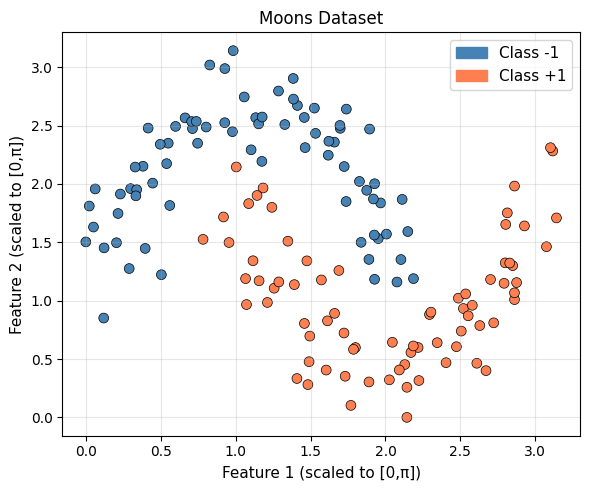

In [ ]:
X_raw, y_raw = make_moons(n_samples=150, noise=0.15, random_state=42)
y_raw = np.where(y_raw == 0, -1, 1)  # labels in {-1, +1}

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_raw, test_size=0.25, random_state=42, stratify=y_raw
)
X_train = np.array(X_train, requires_grad=False)
X_test  = np.array(X_test,  requires_grad=False)
y_train = np.array(y_train, requires_grad=False)
y_test  = np.array(y_test,  requires_grad=False)

print(f'Training: {len(X_train)} samples  |  Test: {len(X_test)} samples')

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['steelblue' if y == -1 else 'coral' for y in y_raw]
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, edgecolors='k', linewidths=0.5, s=50)
p1 = mpatches.Patch(color='steelblue', label='Class -1')
p2 = mpatches.Patch(color='coral', label='Class +1')
ax.legend(handles=[p1, p2], fontsize=11)
ax.set_xlabel('Feature 1 (scaled to [0,π])', fontsize=11)
ax.set_ylabel('Feature 2 (scaled to [0,π])', fontsize=11)
ax.set_title('Moons Dataset', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('moons_dataset.png', dpi=120, bbox_inches='tight')
plt.show()


In [9]:
dev_cls = qml.device('default.qubit', wires=2)

@qml.qnode(dev_cls, diff_method='parameter-shift')
def classifier_circuit(params, x):
    qml.AngleEmbedding(x, wires=range(2), rotation='Y')
    qml.StronglyEntanglingLayers(weights=params, wires=range(2))
    return qml.expval(qml.PauliZ(0))

def cost_fn(params, X, y):
    preds = np.array([classifier_circuit(params, x) for x in X])
    return np.mean((preds - y) ** 2)

def predict_label(raw_output):
    return 1 if raw_output >= 0 else -1

def accuracy(params, X, y):
    preds = np.array([predict_label(float(classifier_circuit(params, x))) for x in X])
    return np.mean(preds == y)

np.random.seed(0)
shape_cls = qml.StronglyEntanglingLayers.shape(n_layers=3, n_wires=2)
params_cls = np.random.uniform(0, 2*np.pi, size=shape_cls, requires_grad=True)

opt = qml.AdamOptimizer(stepsize=0.1)
n_epochs = 60
batch_size = 20
log_epochs, train_losses, test_losses, train_accs, test_accs = [], [], [], [], []

print('Training VQC binary classifier (parameter-shift rule, Adam optimizer)...')
for epoch in range(n_epochs):
    idx = np.random.choice(len(X_train), batch_size, replace=False)
    params_cls, _ = opt.step_and_cost(lambda p: cost_fn(p, X_train[idx], y_train[idx]), params_cls)

    if epoch % 10 == 0 or epoch == n_epochs - 1:
        trl = cost_fn(params_cls, X_train, y_train)
        tel = cost_fn(params_cls, X_test,  y_test)
        tra = accuracy(params_cls, X_train, y_train)
        tea = accuracy(params_cls, X_test,  y_test)
        log_epochs.append(epoch)
        train_losses.append(float(trl)); test_losses.append(float(tel))
        train_accs.append(float(tra));   test_accs.append(float(tea))
        print(f'  Epoch {epoch:3d} | Loss Train/Test: {trl:.4f}/{tel:.4f} | Acc Train/Test: {tra:.2%}/{tea:.2%}')

print(f'\nFinal Test Accuracy: {accuracy(params_cls, X_test, y_test):.2%}')


Training VQC binary classifier (parameter-shift rule, Adam optimizer)...
  Epoch   0 | Loss Train/Test: 0.9758/0.8709 | Acc Train/Test: 52.68%/60.53%
  Epoch  10 | Loss Train/Test: 0.5975/0.5060 | Acc Train/Test: 83.04%/78.95%
  Epoch  20 | Loss Train/Test: 0.4928/0.3708 | Acc Train/Test: 80.36%/94.74%
  Epoch  30 | Loss Train/Test: 0.4728/0.3787 | Acc Train/Test: 83.04%/84.21%
  Epoch  40 | Loss Train/Test: 0.4634/0.3612 | Acc Train/Test: 83.04%/86.84%
  Epoch  50 | Loss Train/Test: 0.4457/0.3346 | Acc Train/Test: 85.71%/89.47%
  Epoch  59 | Loss Train/Test: 0.4526/0.3550 | Acc Train/Test: 84.82%/86.84%

Final Test Accuracy: 86.84%


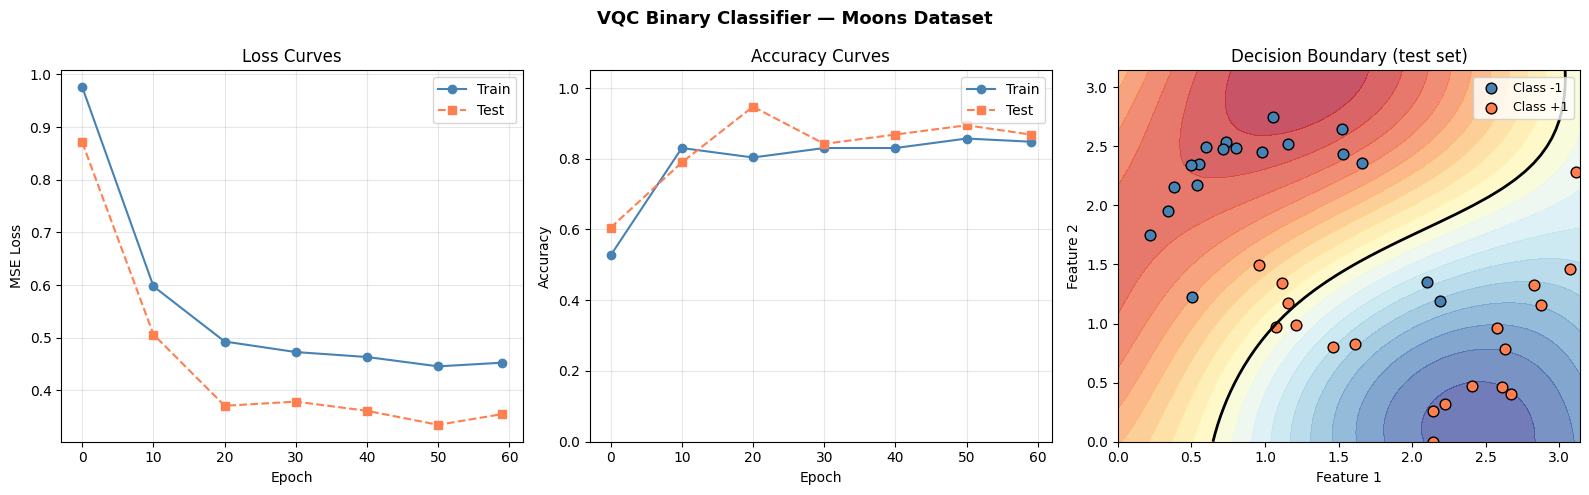

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(log_epochs, train_losses, 'o-', label='Train', color='steelblue')
axes[0].plot(log_epochs, test_losses,  's--', label='Test',  color='coral')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(log_epochs, train_accs, 'o-', label='Train', color='steelblue')
axes[1].plot(log_epochs, test_accs,  's--', label='Test',  color='coral')
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

xx, yy = np.meshgrid(np.linspace(0, np.pi, 45), np.linspace(0, np.pi, 45))
grid_pts = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([float(classifier_circuit(params_cls, pt)) for pt in grid_pts]).reshape(xx.shape)

axes[2].contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.7)
axes[2].contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
axes[2].scatter(X_test[y_test==-1, 0], X_test[y_test==-1, 1], c='steelblue', edgecolors='k', s=60, label='Class -1')
axes[2].scatter(X_test[y_test==1,  0], X_test[y_test==1,  1], c='coral',     edgecolors='k', s=60, label='Class +1')
axes[2].set_xlabel('Feature 1'); axes[2].set_ylabel('Feature 2')
axes[2].set_title('Decision Boundary (test set)'); axes[2].legend(fontsize=9)

plt.suptitle('VQC Binary Classifier — Moons Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vqc_classifier_results.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 6. Homework

Submit a Jupyter notebook with all cells executed and clear written explanations in markdown cells. Code alone is not sufficient — interpret every result.

---

### Problem 1 — Theoretical: PSR Derivation

For a gate $G(\theta) = e^{-i\theta H/2}$ where $H$ is Hermitian with eigenvalues $\{+1, -1\}$:

a) Show that $f(\theta) = \langle \psi | G^\dagger(\theta)\, O\, G(\theta) | \psi \rangle$ can be written as $A\cos\theta + B\sin\theta + C$.

b) Using this form, derive the PSR: $\partial_\theta f = \frac{1}{2}[f(\theta + \pi/2) - f(\theta - \pi/2)]$.

---

### Problem 2 — Theoretical: Quantum Kernel Analysis

a) For 2-qubit `AngleEmbedding` with RY rotations, derive the analytical form of $k(\mathbf{x}, \mathbf{x}') = |\langle\phi(\mathbf{x})|\phi(\mathbf{x}')\rangle|^2$.

b) Show that this kernel is the product of two cosine-squared terms. What well-known classical kernel does this resemble?

c) When are two data points $\mathbf{x}$ and $\mathbf{x}'$ **maximally dissimilar** under this kernel (i.e., $k = 0$)? Give a geometric interpretation.

d) The kernel matrix $K$ has diagonal entries equal to 1. Does this mean the quantum kernel is normalized in the sense of $\|\phi(\mathbf{x})\|=1$ for all $\mathbf{x}$? Justify.

---

### Problem 3 — Coding: VQC on Iris Dataset

Build a VQC binary classifier to distinguish **Iris setosa** from **Iris versicolor** using only the first 2 features.

Requirements:
- Scale features to $[0, \pi]$
- Use at least 3 layers of `StronglyEntanglingLayers`
- Train with Adam for at least 100 epochs
- Report train and test accuracy
- Plot training loss and accuracy curves
- Plot the decision boundary over the **test set**
- Written discussion: Does the VQC overfit? How do you know?

```python
from sklearn.datasets import load_iris
```

---

### Problem 4 — Coding + Theory: Quantum Kernel SVM

Using the `quantum_kernel` function from Section 2.5:

a) Compute the full kernel matrix $K$ for the Iris binary task (same data split as Problem 3).

b) Verify that $K$ is symmetric and positive semi-definite.

c) Train `sklearn.svm.SVC(kernel='precomputed')` using $K$ and report test accuracy.

---

### Problem 5 — Research Reading

Read: *Havlicek et al. (2019). Supervised learning with quantum-enhanced feature spaces. Nature.*

Write a structured summary (max 500 words) covering:
- The main claim
- The ZZ feature map construction
- The experimental evidence (both simulated and real hardware results)
- One limitation or open question you identify

---